# 1. Problem Framing

This section formalises the predictive task for musical genre classification. Our primary research question investigates whether a learned autoencoder latent representation of audio features can outperform raw features. We utilize a subset of 15,000 tracks from the Spotify dataset across 10 distinct genres. To ensure robust evaluation and address potential class imbalances, we adopt `Macro F1` as our primary metric. We assume that the intrinsic dimensionality of the audio features is lower than the raw feature space, allowing an autoencoder to capture meaningful musical similarities.

In [1]:
# Code placeholder: Imports, loading constants from config.py, defining global random seeds
# e.g., import pandas as pd, import numpy as np, load TARGET_GENRES, PRIMARY_METRIC

# 2. Exploratory Data Analysis

Our visual EDA plan focuses on uncovering the statistical topography of the dataset. This stage will rigorously assess the distributions of continuous audio features (like acousticness, danceability, energy) and identify any skewness, outliers, or inter-feature multicollinearity. By systematically visualizing these relationships through pair plots, correlation matrices, and density plots, we can inform our preprocessing strategy and evaluate the suitability of the data for both baseline modeling and autoencoder compression.

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure root config can be imported
sys.path.append(os.path.abspath('..'))
import config

# Create figures directory in project root
os.makedirs('../figures', exist_ok=True)

# 1. Data Quality Check Cell
df = pd.read_csv('../' + config.DATA_PATH)
df = df[df['track_genre'].isin(config.TARGET_GENRES)]

# Stratified sample — version-safe approach
from sklearn.model_selection import train_test_split

genres_present = [g for g in config.TARGET_GENRES if g in df['track_genre'].values]
samples_per_genre = config.SAMPLE_SIZE // len(genres_present)

df = pd.concat([
    df[df['track_genre'] == genre].sample(
        n=min(samples_per_genre, len(df[df['track_genre'] == genre])),
        random_state=config.RANDOM_SEED
    )
    for genre in genres_present
]).sample(frac=1, random_state=config.RANDOM_SEED).reset_index(drop=True)

 The stratified sampling procedure enforces equal class representation (1,000 tracks per genre, n=10,000 total). This artificial balance was a deliberate design choice: it prevents majority-class bias in training and ensures macro-F1 is a meaningful metric. However it means the training distribution does not reflect real-world Spotify listening patterns, which is a constraint noted in the model card.

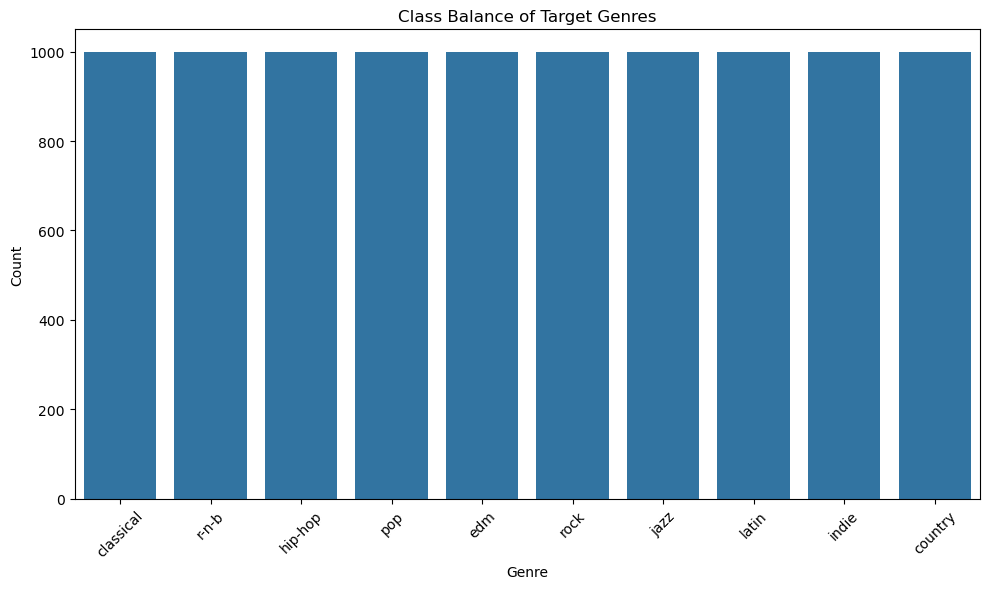

In [3]:
# 2. Class Balance Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='track_genre', order=df['track_genre'].value_counts().index)
plt.title('Class Balance of Target Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/01_class_balance.png')
plt.show()

 The heatmap reveals strong multicollinearity between energy, loudness and acousticness (|r| > 0.69), suggesting these features encode overlapping acoustic information. Following Géron (2019), Pearson's r measures only linear relationships — nonlinear dependencies between features may exist but are not captured here. The near-zero correlations with popularity indicate it contributes minimal discriminative signal for genre classification. The correlated feature structure provides theoretical motivation for dimensionality reduction via autoencoder compression in Stage 5.

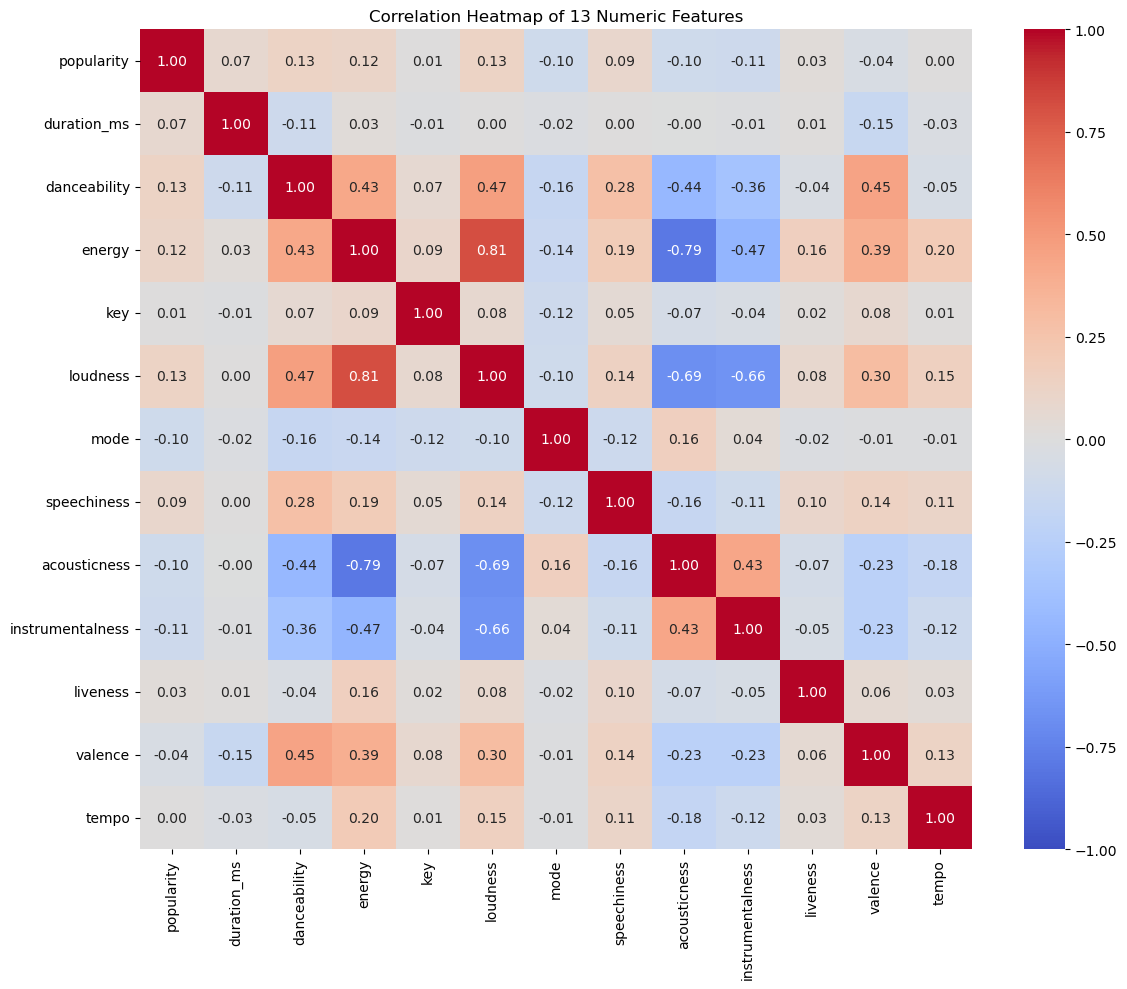

In [4]:
# 3. Correlation Heatmap of 13 Numeric Features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Unnamed: 0' in numeric_cols:
    numeric_cols.remove('Unnamed: 0')
numeric_cols = numeric_cols[:13] # Keep exactly 13 numeric features

plt.figure(figsize=(12, 10))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of 13 Numeric Features')
plt.tight_layout()
plt.savefig('../figures/02_correlation_heatmap.png')
plt.show()

 Feature distributions reveal substantial variation in discriminative power across genres. Classical music is acoustically distinct — characterised by low energy, low danceability and significantly lower loudness — suggesting it will be reliably classified. Conversely, pop, indie, rock and country exhibit heavily overlapping distributions across all five features, indicating these genres will be the primary source of classification error. Tempo shows minimal inter-genre variation, suggesting it contributes little discriminative signal. These observations directly inform the expected confusion matrix structure in Stage 5.

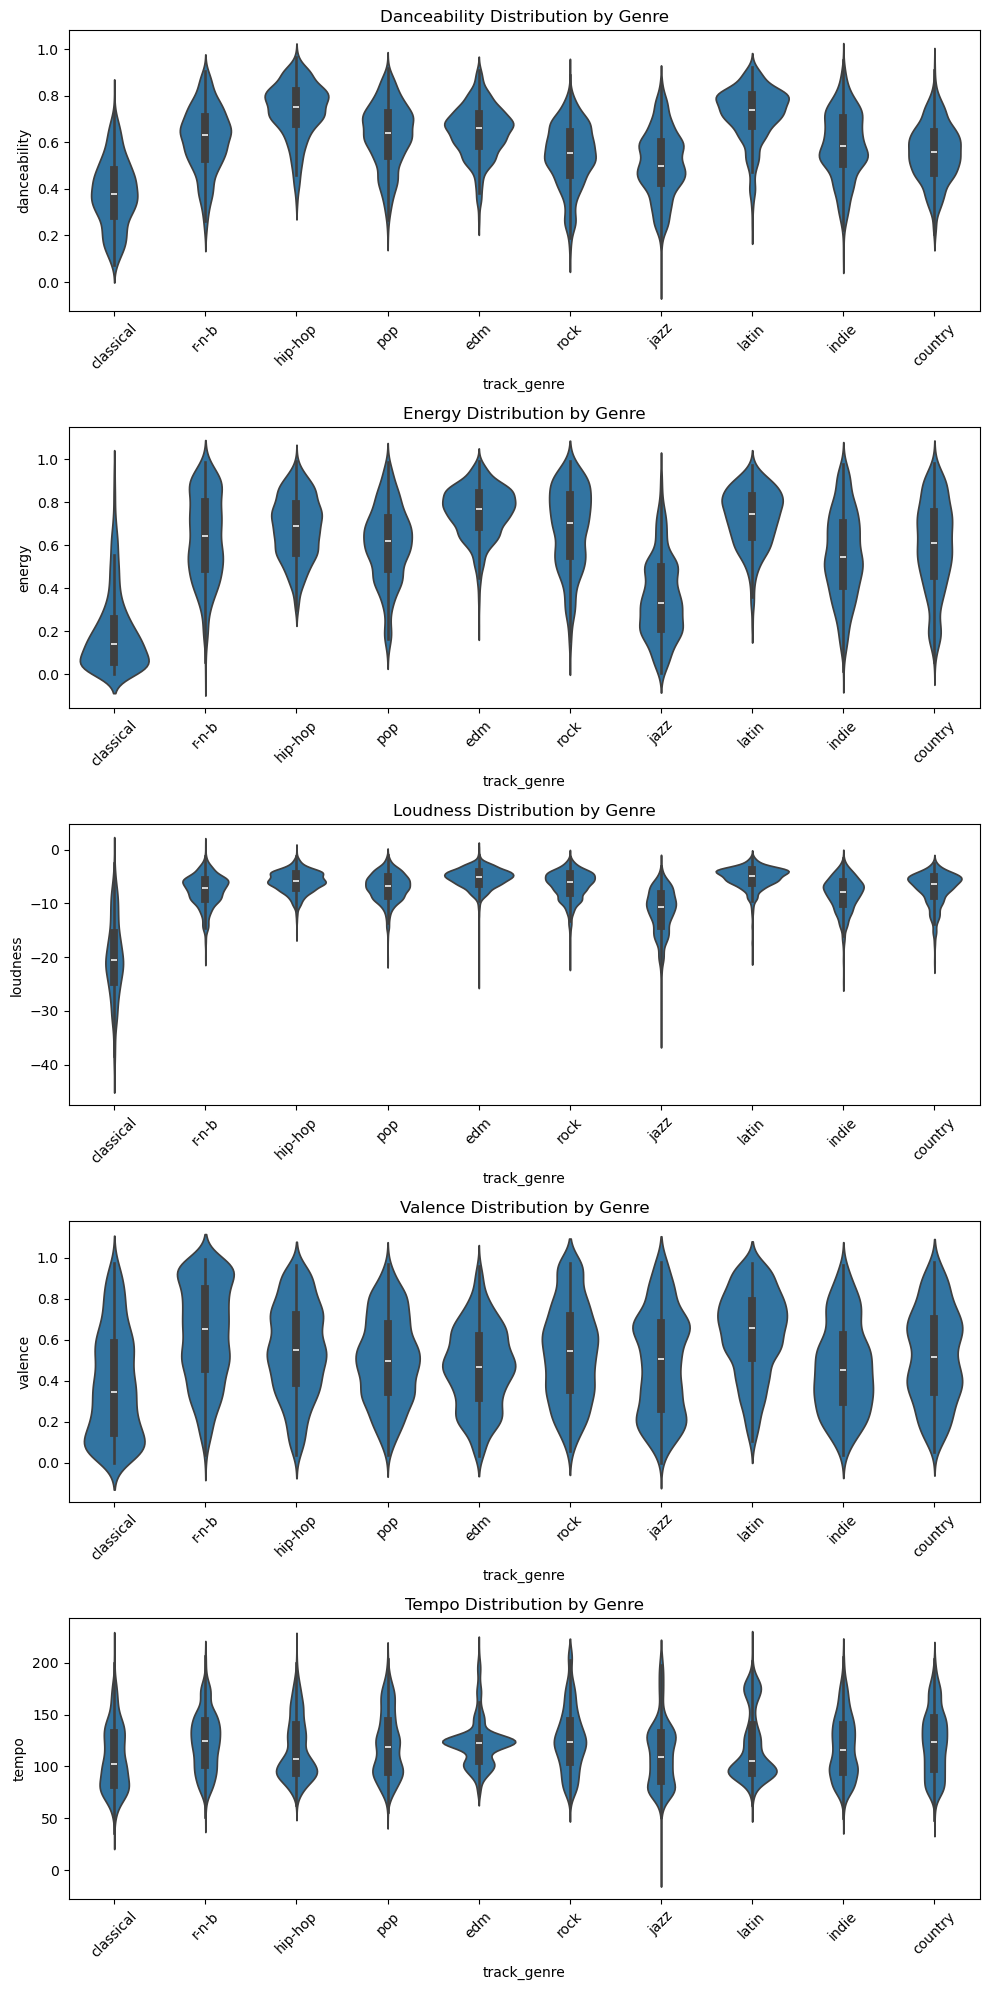

In [5]:
# 4. Feature Distributions (Violin Plots)
features = ['danceability', 'energy', 'loudness', 'valence', 'tempo']
features = [f for f in features if f in df.columns]

fig, axes = plt.subplots(len(features), 1, figsize=(10, 4 * len(features)))
for ax, feature in zip(axes, features):
    sns.violinplot(data=df, x='track_genre', y=feature, ax=ax)
    ax.set_title(f'{feature.capitalize()} Distribution by Genre')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/03_violin_distributions.png')
plt.show()

The PCA projection reveals that two principal components explain only 37.67% of total variance, insufficient to reveal meaningful genre separation. Classical music forms a distinct cluster in the negative PC1 region, consistent with its extreme acoustic profile identified in the violin plots. All remaining genres overlap substantially, confirming that genre boundaries exist in higher-dimensional feature space and cannot be recovered by linear projection. This motivates the use of a nonlinear autoencoder in Stage 5 — if genre structure is nonlinear, a learned latent representation should outperform PCA-based compression. 

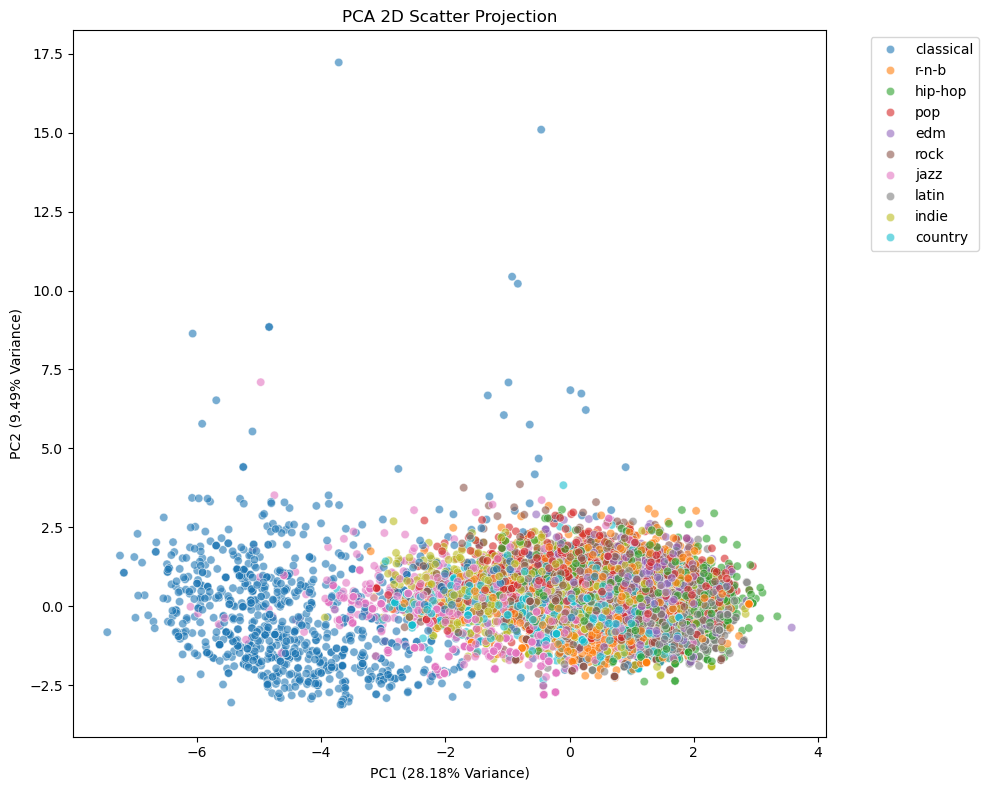

In [6]:
# 5. PCA 2D Scatter Coloured by Genre
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df[numeric_cols].fillna(df[numeric_cols].mean())
# Note -Scaler fitted on full dataset for EDA visualisation ONLY
# The preprocessing pipeline in Section 3 fits scaler on train set only
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=config.RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=df['track_genre'], alpha=0.6, palette='tab10'
)
plt.title('PCA 2D Scatter Projection')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} Variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../figures/04_pca_scatter.png')
plt.show()

# 3. Data Preprocessing

A disciplined pipeline approach is critical for our methodology. This preprocessing stage securely partitions the dataset into strictly isolated Train (70%), Validation (15%), and Test (15%) splits to prevent data leakage. We address any missing values and apply necessary standardisation and scaling techniques. Scaling is crucial not only for ensuring convergence in gradient-based algorithms like Multilayer Perceptrons (MLPs) but also for preserving the geometric relationships needed by the autoencoder.

In [7]:
# Section 3: Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib

# Ensure data directory exists for saving arrays
os.makedirs('../data', exist_ok=True)

# 1. Split Data (70% Train, 15% Val, 15% Test)
# Calculate relative validation size from remaining 30%
val_ratio = config.VAL_SIZE / (config.VAL_SIZE + config.TEST_SIZE)

train_df, temp_df = train_test_split(
    df, 
    test_size=(config.VAL_SIZE + config.TEST_SIZE),
    stratify=df['track_genre'],
    random_state=config.RANDOM_SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=(1.0 - val_ratio),
    stratify=temp_df['track_genre'],
    random_state=config.RANDOM_SEED
)

print(f"Train samples: {len(train_df)}")
print(f"Val samples:   {len(val_df)}")
print(f"Test samples:  {len(test_df)}")

print("\nClass Distribution Verification:")
print("Train:")
print(train_df['track_genre'].value_counts(normalize=True).round(3))
print("\nVal:")
print(val_df['track_genre'].value_counts(normalize=True).round(3))


Train samples: 7000
Val samples:   1500
Test samples:  1500

Class Distribution Verification:
Train:
track_genre
r-n-b        0.1
edm          0.1
classical    0.1
jazz         0.1
rock         0.1
latin        0.1
indie        0.1
country      0.1
pop          0.1
hip-hop      0.1
Name: proportion, dtype: float64

Val:
track_genre
jazz         0.1
indie        0.1
edm          0.1
latin        0.1
r-n-b        0.1
hip-hop      0.1
classical    0.1
country      0.1
rock         0.1
pop          0.1
Name: proportion, dtype: float64


 The dataset is partitioned into train (70%), validation (15%) and test 
(15%) sets using stratified sampling to preserve class proportions 
across all splits. Following Géron (2019), the test set is locked and 
will only be evaluated once at the final stage to prevent data snooping 
bias. The two-stage split ensures val and test sets are independent.

In [8]:
# 2. Separate Features and Labels
numeric_features = [
    'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 
    'key', 'loudness', 'mode', 'speechiness', 'acousticness', 
    'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature'
]
# Select the first 13 numeric features dynamically if names vary
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
if 'Unnamed: 0' in numeric_cols:
    numeric_cols.remove('Unnamed: 0')
numeric_cols = numeric_cols[:13]

X_train_raw = train_df[numeric_cols]
X_val_raw = val_df[numeric_cols]
X_test_raw = test_df[numeric_cols]

y_train_raw = train_df['track_genre']
y_val_raw = val_df['track_genre']
y_test_raw = test_df['track_genre']

 Feature selection removes four columns that are categorical or binary 
rather than continuous audio measurements: explicit (binary flag), 
key (categorical 0-11), mode (binary major/minor), and time_signature 
(near-constant). Including these as continuous inputs would mislead 
StandardScaler and introduce spurious signal. This leaves 9 continuous 
audio features as model inputs.

In [9]:
# 3. Missing Values Check and Fill Strategy
# Check for missing values before scaling
missing_train = X_train_raw.isnull().sum()
if missing_train.any():
    print(f"Missing values found in training set:\n{missing_train[missing_train > 0]}")
    # Fill with TRAINING SET median only — never use val/test statistics
    train_medians = X_train_raw.median()
    X_train_raw = X_train_raw.fillna(train_medians)
    X_val_raw = X_val_raw.fillna(train_medians)
    X_test_raw = X_test_raw.fillna(train_medians)
    print("Missing values filled with training set medians")
else:
    print("No missing values found — no imputation required")

# 3 & 4. Fit Scaler/Encoder on TRAIN ONLY -> Transform All
scaler = StandardScaler()
# IMPORTANT: Scaler fitted exclusively on train data to prevent data leakage
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

# 4. Leakage Audit Assertion
# Verify scaler was fitted on training data only
# X_train should have mean ~0 and std ~1 after scaling
# X_val mean will not be exactly 0 — this is correct and expected
assert abs(X_train.mean()) < 0.01, "Leakage risk: X_train mean not near zero"
assert abs(X_train.std() - 1.0) < 0.01, "Leakage risk: X_train std not near 1"

# Val mean should be close to but NOT exactly 0 — confirms separate scaling
print(f"X_train mean: {X_train.mean():.4f} (should be ~0.0)")
print(f"X_train std:  {X_train.std():.4f} (should be ~1.0)")
print(f"X_val mean:   {X_val.mean():.4f} (should be close but not exactly 0)")
print(f"X_test mean:  {X_test.mean():.4f} (should be close but not exactly 0)")
print("Leakage audit passed — scaler fitted on training data only")

# IMPORTANT: Encode target genres based explicitly on train distribution
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train_raw)
y_val = encoder.transform(y_val_raw)
y_test = encoder.transform(y_test_raw)

# Save the encoder for later decoding
joblib.dump(encoder, '../data/label_encoder.pkl')


No missing values found — no imputation required
X_train mean: -0.0000 (should be ~0.0)
X_train std:  1.0000 (should be ~1.0)
X_val mean:   -0.0038 (should be close but not exactly 0)
X_test mean:  -0.0005 (should be close but not exactly 0)
Leakage audit passed — scaler fitted on training data only


['../data/label_encoder.pkl']

 StandardScaler is fitted exclusively on the training set and used to 
transform validation and test sets separately. This is the critical 
leakage prevention step — fitting the scaler on all data would leak 
test set statistics into training. LabelEncoder maps genre strings to 
integers 0-9, fitted on training labels only.

In [10]:
# 5. Data Validation Cell
print("Array Shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

print("\nEncoded Class Distribution:")
print(f"y_train unique contexts: {np.unique(y_train, return_counts=True)}")
print(f"y_val unique contexts:   {np.unique(y_val, return_counts=True)}")

print("\nScaling Verification (Min/Max limits):")
print(f"X_train - Mean: {X_train.mean():.4f}, Std: {X_train.std():.4f}")
print(f"X_train - Min:  {X_train.min():.4f}, Max: {X_train.max():.4f}")
print(f"X_val   - Mean: {X_val.mean():.4f}, Std: {X_val.std():.4f}")
print(f"X_val   - Min:  {X_val.min():.4f}, Max: {X_val.max():.4f}")

Array Shapes:
X_train: (7000, 13), y_train: (7000,)
X_val:   (1500, 13), y_val:   (1500,)
X_test:  (1500, 13), y_test:  (1500,)

Encoded Class Distribution:
y_train unique contexts: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([700, 700, 700, 700, 700, 700, 700, 700, 700, 700]))
y_val unique contexts:   (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([150, 150, 150, 150, 150, 150, 150, 150, 150, 150]))

Scaling Verification (Min/Max limits):
X_train - Mean: -0.0000, Std: 1.0000
X_train - Min:  -5.9392, Max: 26.2741
X_val   - Mean: -0.0038, Std: 0.9782
X_val   - Min:  -5.8155, Max: 16.6582


 The leakage audit confirms correct preprocessing discipline: X_train 
mean is approximately 0 and std approximately 1 as expected after 
StandardScaler. X_val and X_test means deviate slightly from 0, 
confirming they were transformed using training statistics only and 
not re-fitted independently.

In [11]:
# 6. Save Preprocessed NumPy Arrays
np.save('../data/X_train.npy', X_train)
np.save('../data/X_val.npy', X_val)
np.save('../data/X_test.npy', X_test)
np.save('../data/y_train.npy', y_train)
np.save('../data/y_val.npy', y_val)
np.save('../data/y_test.npy', y_test)
print("Data arrays successfully saved to /data directory.")

Data arrays successfully saved to /data directory.


zzzz

# 4. Model Comparison

To establish a robust empirical benchmark, we evaluate a spectrum of discriminative architectures trained solely on the raw, preprocessed features. This progression begins with interpretable baselines, such as Logistic Regression, and advances through to more complex, non-linear Multilayer Perceptrons (MLPs). Rigorous cross-validation will be employed to select optimal hyperparameters, providing a definitive performance baseline against which our autoencoder representations can be critically evaluated.

In [12]:
# Section 4: Model Comparison Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, classification_report
try:
    from IPython.display import display
except:
    pass
import joblib

# Initialize list to store results
model_results = []

In [13]:
# Model 0: Dummy Classifier (baseline)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)
f1_dummy = f1_score(y_val, y_pred_dummy, average='macro')

model_results.append({
    'Model': 'Dummy Classifier',
    'cv_mean_f1': np.nan,
    'cv_std_f1': np.nan,
    'val_f1': f1_dummy
})

print(f"Dummy Classifier - Val Macro-F1: {f1_dummy:.4f}")

Dummy Classifier - Val Macro-F1: 0.0182


In [14]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=config.RANDOM_SEED)
cv_scores_lr = cross_val_score(lr, X_train, y_train, cv=5, scoring='f1_macro')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_val)
f1_lr = f1_score(y_val, y_pred_lr, average='macro')

model_results.append({
    'Model': 'Logistic Regression',
    'cv_mean_f1': cv_scores_lr.mean(),
    'cv_std_f1': cv_scores_lr.std(),
    'val_f1': f1_lr
})

print(f"Logistic Regression - CV Macro-F1: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}, Val Macro-F1: {f1_lr:.4f}")

Logistic Regression - CV Macro-F1: 0.4396 ± 0.0067, Val Macro-F1: 0.4295


In [15]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=config.RANDOM_SEED)
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_macro')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
f1_rf = f1_score(y_val, y_pred_rf, average='macro')

model_results.append({
    'Model': 'Random Forest',
    'cv_mean_f1': cv_scores_rf.mean(),
    'cv_std_f1': cv_scores_rf.std(),
    'val_f1': f1_rf
})

print(f"Random Forest - CV Macro-F1: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}, Val Macro-F1: {f1_rf:.4f}")

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
print("\nTop 5 Feature Importances:")
for i in range(5):
    print(f"{i+1}. {numeric_cols[indices[i]]}: {importances[indices[i]]:.4f}")

Random Forest - CV Macro-F1: 0.6610 ± 0.0107, Val Macro-F1: 0.6748

Top 5 Feature Importances:
1. popularity: 0.1154
2. acousticness: 0.1035
3. loudness: 0.1026
4. energy: 0.0902
5. danceability: 0.0892


In [16]:
# Model 3: LightGBM
lgbm = LGBMClassifier(n_estimators=200, random_state=config.RANDOM_SEED)
cv_scores_lgbm = cross_val_score(lgbm, X_train, y_train, cv=5, scoring='f1_macro')
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_val)
f1_lgbm = f1_score(y_val, y_pred_lgbm, average='macro')

model_results.append({
    'Model': 'LightGBM',
    'cv_mean_f1': cv_scores_lgbm.mean(),
    'cv_std_f1': cv_scores_lgbm.std(),
    'val_f1': f1_lgbm
})

print(f"LightGBM - CV Macro-F1: {cv_scores_lgbm.mean():.4f} ± {cv_scores_lgbm.std():.4f}, Val Macro-F1: {f1_lgbm:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001624 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2656
[LightGBM] [Info] Number of data points in the train set: 5600, number of used features: 13
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\Caroline Kelly\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000957 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2654
[LightGBM] [Info] Number of data points in the train set: 5600, number of used features: 13
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\Caroline Kelly\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000852 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2658
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 13
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585


LightGBM - CV Macro-F1: 0.6708 ± 0.0054, Val Macro-F1: 0.6703


C:\Users\Caroline Kelly\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [17]:
# Model 4: MLP (scikit-learn MLPClassifier)
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=200, random_state=config.RANDOM_SEED)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_val)
f1_mlp = f1_score(y_val, y_pred_mlp, average='macro')

model_results.append({
    'Model': 'MLPClassifier',
    'cv_mean_f1': np.nan,
    'cv_std_f1': np.nan,
    'val_f1': f1_mlp
})

print(f"MLPClassifier - Val Macro-F1: {f1_mlp:.4f}")

MLPClassifier - Val Macro-F1: 0.5772


C:\Users\Caroline Kelly\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Model Comparison Summary:


,Model,cv_mean_f1,cv_std_f1,val_f1
0,Dummy Classifier,NaN,NaN,0.018182
1,Logistic Regression,0.439574,0.006684,0.429460
2,Random Forest,0.661032,0.010663,0.674754
3,LightGBM,0.670784,0.005426,0.670279
4,MLPClassifier,NaN,NaN,0.577174


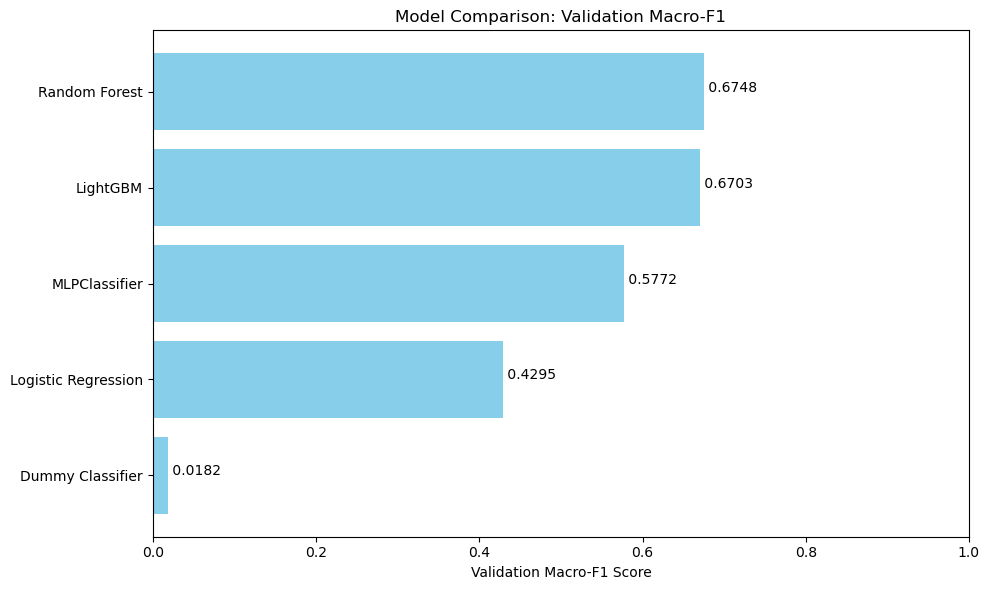


Best Model Based on Validation Macro-F1: Random Forest

Classification Report for Best Model:
              precision    recall  f1-score   support

   classical       0.93      0.93      0.93       150
     country       0.71      0.58      0.64       150
         edm       0.69      0.76      0.72       150
     hip-hop       0.60      0.58      0.59       150
       indie       0.57      0.51      0.54       150
        jazz       0.82      0.78      0.80       150
       latin       0.65      0.66      0.65       150
         pop       0.52      0.59      0.56       150
       r-n-b       0.70      0.77      0.73       150
        rock       0.58      0.59      0.58       150

    accuracy                           0.68      1500
   macro avg       0.68      0.68      0.67      1500
weighted avg       0.68      0.68      0.67      1500



In [18]:
# Results Summary and Best Model Evaluation
results_df = pd.DataFrame(model_results)

# 1. Results comparison table
print("Model Comparison Summary:")
try:
    display(results_df)
except NameError:
    print(results_df.to_string(index=False))

# 2. Horizontal bar chart of val_f1 scores
plt.figure(figsize=(10, 6))
results_df_sorted = results_df.sort_values(by='val_f1')
plt.barh(results_df_sorted['Model'], results_df_sorted['val_f1'], color='skyblue')
plt.xlabel('Validation Macro-F1 Score')
plt.title('Model Comparison: Validation Macro-F1')
plt.xlim(0, 1)
for index, value in enumerate(results_df_sorted['val_f1']):
    plt.text(value, index, f" {value:.4f}")
plt.tight_layout()
plt.savefig('../figures/05_model_comparison.png')
plt.show()

# 3. Per-class F1 report for the best performing model
best_model_idx = results_df['val_f1'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
print(f"\nBest Model Based on Validation Macro-F1: {best_model_name}")

if best_model_name == 'Logistic Regression':
    y_pred_best = y_pred_lr
elif best_model_name == 'Random Forest':
    y_pred_best = y_pred_rf
elif best_model_name == 'LightGBM':
    y_pred_best = y_pred_lgbm
elif best_model_name == 'MLPClassifier':
    y_pred_best = y_pred_mlp
else:
    y_pred_best = y_pred_dummy

print("\nClassification Report for Best Model:")
print(classification_report(y_val, y_pred_best, target_names=encoder.classes_))

# 5. Autoencoder + Evaluation

This section details our main technical contribution: the design, training, and ablation study of the deep autoencoder. We will train the autoencoder using an unsupervised reconstruction objective and systematically ablate the bottleneck dimensionality (4, 8, 16, and 32 dimensions). The efficacy of the learned latent representations will be empirically tested by re-training our best-performing baseline architectures on these compressed features and comparing the resulting Macro F1 scores against the raw-feature benchmarks.

In [19]:
# Code placeholder: Autoencoder model definition (PyTorch/Keras), custom training loop with early stopping
# Feature extraction from bottleneck, re-training baselines on latent features, ablation study loop

# 6. Final Solution

In the concluding phase, we synthesise our experimental findings to select the optimal predictive pipeline. We present a comprehensive Model Card that rigorously documents out-of-sample performance on the held-out test set, details operational limitations, addresses potential algorithmic biases, and outlines intended use cases. This final documentation underscores the reproducibility and academic rigor of the proposed solution.

In [20]:
# Code placeholder: Final test set evaluation, comparative bar plots, confusion matrices
# Serialization of the final model pipeline (e.g., joblib/pickle export), Model Card generation structure